# QoS Buddy -- Optimization Agent
## Phase 1: Data Preparation & Phase 2: Bandit Policy Benchmark

**Owner:** Optimization Agent Team
**Objective:** Build and evaluate contextual bandit policies for autonomous QoS action selection
**Architecture:** OADAL Closed Loop (Observe -> Analyze -> Decide -> Act -> Learn)

---

### Six-Agent Architecture

| Agent | OADAL Role | Responsibility |
|-------|-----------|----------------|
| Monitoring | **Observe** | Collect real-time QoS telemetry |
| Detection | **Analyze** | Identify anomalies in KPI streams |
| Prediction | **Analyze** | Forecast degradation |
| Diagnostic | **Decide** | Determine root cause |
| **Optimization** | **Act** | Select and execute corrective actions |
| Reporting | **Learn** | Document outcomes, feed back |

### Models Compared (Phase 2)

| # | Policy | Description |
|---|--------|-------------|
| 1 | **LinUCB (Disjoint)** | Classical linear contextual bandit -- baseline |
| 2 | **Neural Thompson Sampling** | MLP ensemble with bootstrap uncertainty -- captures non-linear reward |
| 3 | **LLM-Guided LinUCB** | Local LLM (qwen2.5:1.5b via Ollama) injects domain priors into UCB |

### Policy and Safety Gate

Every action must pass a Policy Gate before execution:

| Criterion | Check |
|-----------|-------|
| Risk Level | Within acceptable threshold |
| Impact Radius | Affected users/services bounded |
| Change Window | Respects maintenance windows |
| Rollback | Reversible actions preferred |
| Regulatory | Telecom compliance |
| Resource Limits | Within capacity |

Gate outcomes: **APPROVED** / **PENDING_APPROVAL** / **REJECTED** / **DEFERRED**

Human oversight modes: *Recommendation-Only* / *Semi-Automatic* / *Controlled Autonomy*

In [1]:
from __future__ import annotations

import glob
import json
import os
import time
import warnings
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import softmax as scipy_softmax
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

WORKDIR = os.getcwd()
PURGE_GAP_MIN = 30
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
assert abs((TRAIN_FRAC + VAL_FRAC + TEST_FRAC) - 1.0) < 1e-9

RC_CLASSES = [
    "RC_WEAK_SIGNAL", "RC_SINR_DEGRADED", "RC_HO_FAILURE", "RC_PRB_CONGESTION",
    "RC_TRANSPORT_DELAY", "RC_CQI_MISMATCH", "RC_COVERAGE_HOLE", "RC_CAPACITY_OVERLOAD",
]

print(f'Run timestamp : {datetime.now(timezone.utc).isoformat(timespec="seconds")}')
print(f'Seed          : {SEED}')
print(f'Working dir   : {WORKDIR}')
print(f'Split ratio   : train={TRAIN_FRAC:.0%} / val={VAL_FRAC:.0%} / test={TEST_FRAC:.0%}')

Run timestamp : 2026-04-16T03:43:18+00:00
Seed          : 42
Working dir   : C:\Users\amani\Downloads\pi - Copy - Copy
Split ratio   : train=70% / val=15% / test=15%


## Phase 1 -- Data Preparation

In [2]:
# --- 1. Input Discovery & Ingestion ---
qos_paths = sorted(glob.glob(os.path.join(WORKDIR, 'qos_timeseries_choice_*.csv')))
inc_paths = sorted(glob.glob(os.path.join(WORKDIR, 'incidents_choice_*.csv')))
assert qos_paths, 'No QoS CSV files found.'
assert inc_paths, 'No incident CSV files found.'
print(f'Discovered {len(qos_paths)} QoS files, {len(inc_paths)} incident files')

def parse_choice_date(path):
    name = os.path.basename(path).replace('.csv', '')
    parts = name.split('_')
    return int(parts[-2]), parts[-1]

qos_frames, qos_meta = [], []
for p in qos_paths:
    choice, ymd = parse_choice_date(p)
    df = pd.read_csv(p)
    df['source_file'], df['choice_id'], df['date_key'] = os.path.basename(p), choice, ymd
    qos_frames.append(df)
    ts = pd.to_datetime(df['timestamp'], errors='coerce') if 'timestamp' in df.columns else pd.Series(dtype='datetime64[ns]')
    qos_meta.append({'file': os.path.basename(p), 'rows': len(df), 'min_ts': ts.min(), 'max_ts': ts.max(),
                     'anomalies': int(df['anomaly_flag'].fillna(False).astype(bool).sum()) if 'anomaly_flag' in df.columns else 0})

inc_frames, inc_meta = [], []
for p in inc_paths:
    choice, ymd = parse_choice_date(p)
    df = pd.read_csv(p)
    df['source_file'], df['choice_id'], df['date_key'] = os.path.basename(p), choice, ymd
    inc_frames.append(df)
    s = pd.to_datetime(df.get('start_timestamp', pd.Series(dtype=str)), errors='coerce')
    inc_meta.append({'file': os.path.basename(p), 'rows': len(df), 'min_start': s.min(), 'max_start': s.max()})

qos_raw = pd.concat(qos_frames, ignore_index=True)
inc_raw = pd.concat(inc_frames, ignore_index=True)

display(pd.DataFrame(qos_meta).sort_values('file').reset_index(drop=True))
display(pd.DataFrame(inc_meta).sort_values('file').reset_index(drop=True))
print(f'\nTotal QoS rows: {len(qos_raw):,} | Total incidents: {len(inc_raw):,}')

Discovered 13 QoS files, 13 incident files


,file,rows,min_ts,max_ts,anomalies
0,qos_timeseries_choice_11_20260327.csv,250,2026-03-27 17:22:08.968812,2026-03-27 23:26:21.525937,94
1,qos_timeseries_choice_11_20260328.csv,416,2026-03-28 01:48:27.317433,2026-03-28 11:25:28.173201,42
2,qos_timeseries_choice_11_20260329.csv,15,2026-03-29 20:06:25.272453,2026-03-29 22:33:23.885267,4
3,qos_timeseries_choice_11_20260330.csv,267,2026-03-30 11:38:58.160148,2026-03-30 15:26:13.767823,30
4,qos_timeseries_choice_11_20260402.csv,82,2026-04-02 22:57:29.482350,2026-04-02 23:59:37.004784,81
5,qos_timeseries_choice_11_20260403.csv,406,2026-04-03 00:00:11.611573,2026-04-03 19:51:36.222182,405
6,qos_timeseries_choice_11_20260404.csv,555,2026-04-04 16:03:22.055369,2026-04-04 21:32:33.200591,482
7,qos_timeseries_choice_11_20260405.csv,91,2026-04-05 01:45:16.954405,2026-04-05 02:38:15.114399,91
8,qos_timeseries_choice_12_20260328.csv,64,2026-03-28 00:19:21.436173,2026-03-28 20:37:16.404905,22
9,qos_timeseries_choice_12_20260329.csv,51,2026-03-29 03:10:53.553728,2026-03-29 05:24:20.067773,9


,file,rows,min_start,max_start
0,incidents_choice_11_20260327.csv,80,2026-03-27 17:22:08.968812,2026-03-27 23:22:54.064448
1,incidents_choice_11_20260328.csv,42,2026-03-28 01:52:59.024282,2026-03-28 11:01:21.483859
2,incidents_choice_11_20260329.csv,3,2026-03-29 22:21:51.772682,2026-03-29 22:33:23.885267
3,incidents_choice_11_20260330.csv,30,2026-03-30 11:38:58.160148,2026-03-30 15:24:21.794371
4,incidents_choice_11_20260402.csv,3,2026-04-02 22:57:29.482350,2026-04-02 23:07:50.056097
5,incidents_choice_11_20260403.csv,13,2026-04-02 23:10:31.597155,2026-04-03 19:43:48.607791
6,incidents_choice_11_20260404.csv,73,2026-04-04 16:03:22.055369,2026-04-04 21:24:57.649505
7,incidents_choice_11_20260405.csv,2,2026-04-05 01:45:16.954405,2026-04-05 01:46:02.387720
8,incidents_choice_12_20260328.csv,16,2026-03-28 00:19:21.436173,2026-03-28 13:03:16.996907
9,incidents_choice_12_20260329.csv,6,2026-03-29 04:31:44.846743,2026-03-29 05:18:44.640968



Total QoS rows: 3,128 | Total incidents: 301


In [3]:
# --- 2. Schema Normalization ---
required_qos = [
    'timestamp', 'node_id', 'latency_ms', 'jitter_ms', 'packet_loss_pct', 'throughput_mbps',
    'anomaly_flag', 'anomaly_type', 'anomaly_score', 'rssi_dbm', 'rsrp_dbm', 'rsrq_db',
    'sinr_db', 'cqi', 'tcp_retransmit_rate', 'queue_length', 'bandwidth_util_pct',
    'channel_util_pct', 'active_connections', 'ho_success_rate_pct', 'ho_status',
]
required_inc = ['start_timestamp', 'end_timestamp', 'node_id', 'incident_type', 'severity']

missing_q = [c for c in required_qos if c not in qos_raw.columns]
missing_i = [c for c in required_inc if c not in inc_raw.columns]
assert not missing_q, f'Missing QoS cols: {missing_q}'
assert not missing_i, f'Missing Inc cols: {missing_i}'

qos = qos_raw.copy()
inc = inc_raw.copy()

qos['timestamp'] = pd.to_datetime(qos['timestamp'], errors='coerce')
for c in ['latency_ms','jitter_ms','packet_loss_pct','throughput_mbps','anomaly_score',
          'rssi_dbm','rsrp_dbm','rsrq_db','sinr_db','cqi','tcp_retransmit_rate',
          'queue_length','bandwidth_util_pct','channel_util_pct','active_connections','ho_success_rate_pct']:
    qos[c] = pd.to_numeric(qos[c], errors='coerce')
qos['anomaly_flag'] = qos['anomaly_flag'].fillna(False).astype(bool)
qos['anomaly_type'] = qos['anomaly_type'].fillna('normal').str.strip().str.lower()
qos['node_id'] = qos['node_id'].astype(str).str.strip()
qos['ho_status'] = qos['ho_status'].fillna('none').astype(str).str.strip().str.lower()

inc['start_timestamp'] = pd.to_datetime(inc['start_timestamp'], errors='coerce')
inc['end_timestamp'] = pd.to_datetime(inc['end_timestamp'], errors='coerce')
inc['node_id'] = inc['node_id'].astype(str).str.strip()
inc['incident_type'] = inc['incident_type'].fillna('unknown').str.strip().str.lower()
inc['severity'] = inc['severity'].fillna('unknown').str.strip().str.lower()

bad_end = inc['end_timestamp'].notna() & inc['start_timestamp'].notna() & (inc['end_timestamp'] < inc['start_timestamp'])
inc.loc[bad_end, 'end_timestamp'] = inc.loc[bad_end, 'start_timestamp']

print(f'Schema normalization complete. QoS: {len(qos):,} rows | Incidents: {len(inc):,} rows')

Schema normalization complete. QoS: 3,128 rows | Incidents: 301 rows


In [4]:
# --- 3. Data Quality Gates ---
scope_cols = [c for c in required_qos if c in qos.columns]
missing_pct = qos[scope_cols].isna().mean().sort_values(ascending=False).rename('missing_pct')

dup_count = int(qos.duplicated(subset=['timestamp', 'node_id', 'source_file']).sum())
invalid_ranges = {
    'latency_neg': int((qos['latency_ms'] < 0).fillna(False).sum()),
    'jitter_neg': int((qos['jitter_ms'] < 0).fillna(False).sum()),
    'pkt_loss_oob': int(((qos['packet_loss_pct'] < 0) | (qos['packet_loss_pct'] > 100)).fillna(False).sum()),
    'tp_neg': int((qos['throughput_mbps'] < 0).fillna(False).sum()),
}

qos_s = qos.sort_values(['node_id', 'timestamp']).reset_index(drop=True)
backward = sum(int((g['timestamp'].diff() < pd.Timedelta(0)).sum()) for _, g in qos_s.groupby('node_id'))

MAX_MISS, MAX_DUP = 0.20, 0.01

gate_df = pd.DataFrame([
    {'gate': 'required_schema',  'status': 'PASS', 'detail': 'all fields present'},
    {'gate': 'timestamp_nonnull','status': 'PASS' if qos['timestamp'].notna().all() else 'FAIL',
     'detail': f'nulls={int((~qos["timestamp"].notna()).sum())}'},
    {'gate': 'duplicates',       'status': 'PASS' if (dup_count/max(len(qos),1)) <= MAX_DUP else 'FAIL',
     'detail': f'{dup_count}/{len(qos)}'},
    {'gate': 'invalid_ranges',   'status': 'PASS' if sum(invalid_ranges.values())==0 else 'FAIL',
     'detail': str(invalid_ranges)},
    {'gate': 'temporal_order',   'status': 'PASS' if backward==0 else 'FAIL',
     'detail': f'backward={backward}'},
    {'gate': 'missingness',      'status': 'PASS' if float(missing_pct.max()) <= MAX_MISS else 'FAIL',
     'detail': f'max={float(missing_pct.max()):.3f} ({missing_pct.idxmax()})'},
])
display(gate_df)
assert gate_df[gate_df['status']=='FAIL'].empty, 'Quality gates FAILED'
print('All quality gates PASSED.')

,gate,status,detail
0,required_schema,PASS,all fields present
1,timestamp_nonnull,PASS,nulls=0
2,duplicates,PASS,0/3128
3,invalid_ranges,PASS,"{'latency_neg': 0, 'jitter_neg': 0, 'pkt_loss_..."
4,temporal_order,PASS,backward=0
5,missingness,PASS,max=0.002 (ho_success_rate_pct)


All quality gates PASSED.


In [5]:
# --- 4. Episode Construction ---
qos = qos.sort_values(['node_id', 'timestamp']).reset_index(drop=True)

def build_incident_episodes(inc_df):
    out = inc_df[inc_df['start_timestamp'].notna()].copy()
    if out.empty:
        return out.assign(episode_id=[], episode_source=[], episode_start=[], episode_end=[])
    out['end_timestamp'] = out['end_timestamp'].fillna(out['start_timestamp'])
    out['episode_start'] = out['start_timestamp']
    out['episode_end'] = out[['start_timestamp', 'end_timestamp']].max(axis=1)
    out['episode_source'] = 'incident'
    out = out.sort_values(['node_id', 'episode_start']).reset_index(drop=True)
    out['episode_id'] = [f'E_INC_{i:06d}' for i in range(1, len(out)+1)]
    return out

def build_pseudo_episodes(qos_df, existing, gap_minutes=5):
    existing_ivs = [(r.node_id, r.episode_start, r.episode_end)
                    for r in existing[['node_id','episode_start','episode_end']].itertuples(index=False)] if not existing.empty else []
    pseudo = []
    for node, g in qos_df.sort_values('timestamp').groupby('node_id'):
        g = g[g['timestamp'].notna()].copy()
        g['is_anom'] = g['anomaly_flag'].fillna(False).astype(bool)
        if g.empty:
            continue
        run_id, cur = 0, []
        for row in g.itertuples(index=False):
            if not row.is_anom:
                if cur:
                    run_id += 1
                    pseudo.append((node, run_id, cur[0], cur[-1], len(cur)))
                    cur = []
                continue
            if not cur:
                cur = [row.timestamp]
            elif row.timestamp - cur[-1] <= pd.Timedelta(minutes=gap_minutes):
                cur.append(row.timestamp)
            else:
                run_id += 1
                pseudo.append((node, run_id, cur[0], cur[-1], len(cur)))
                cur = [row.timestamp]
        if cur:
            run_id += 1
            pseudo.append((node, run_id, cur[0], cur[-1], len(cur)))

    p = pd.DataFrame(pseudo, columns=['node_id','run_id','episode_start','episode_end','samples'])
    if p.empty:
        return p
    keep = [not any(r.node_id==n and r.episode_start<=e and r.episode_end>=s for n,s,e in existing_ivs)
            for r in p.itertuples(index=False)]
    p = p[keep].reset_index(drop=True)
    p['episode_source'] = 'pseudo'
    p['episode_id'] = [f'E_PSE_{i:06d}' for i in range(1, len(p)+1)]
    return p

inc_eps = build_incident_episodes(inc)
pseudo_eps = build_pseudo_episodes(qos, inc_eps)

shared = ['episode_id','node_id','episode_start','episode_end','episode_source']
extra = ['incident_type','severity','duration_sec','max_score']
for c in extra:
    for df in (inc_eps, pseudo_eps):
        if c not in df.columns:
            df[c] = np.nan

episodes = pd.concat([inc_eps[shared+extra], pseudo_eps[shared+extra]], ignore_index=True)
episodes['duration_sec'] = episodes['duration_sec'].fillna(
    (episodes['episode_end'] - episodes['episode_start']).dt.total_seconds())

qos_counts = []
for _, ep in episodes.iterrows():
    mask = ((qos['node_id']==ep['node_id']) & (qos['timestamp']>=ep['episode_start']) & (qos['timestamp']<=ep['episode_end']))
    qos_counts.append(int(mask.sum()))
episodes['qos_rows'] = qos_counts

print(f'Episodes: {len(inc_eps)} incident + {len(pseudo_eps)} pseudo = {len(episodes)} total')
print(episodes['episode_source'].value_counts().to_string())

Episodes: 301 incident + 5 pseudo = 306 total
episode_source
incident    301
pseudo        5


In [6]:
# --- 5. Root-Cause Evidence Scoring ---
def past_pct(col, q, cutoff, min_h=20):
    h = qos.loc[qos['timestamp'] < cutoff, col].dropna()
    return float(np.nanpercentile(h, q)) if len(h) >= min_h else np.nan

def cmp_rate(s, thr, d):
    if thr is None or pd.isna(thr):
        return np.nan
    return float((s <= thr).mean()) if d == 'le' else float((s >= thr).mean())

def smean(vals):
    c = [v for v in vals if pd.notna(v)]
    return float(np.mean(c)) if c else 0.0

def score_episode(g, cutoff):
    if g.empty:
        return {k: 0.0 for k in RC_CLASSES} | {'history_support': 0}
    t = {k: past_pct(col, q, cutoff) for k, col, q in [
        ('rssi20','rssi_dbm',20),('rsrp20','rsrp_dbm',20),('rsrq20','rsrq_db',20),
        ('sinr20','sinr_db',20),('sinr10','sinr_db',10),('cqi25','cqi',25),
        ('lat80','latency_ms',80),('q80','queue_length',80),('bw80','bandwidth_util_pct',80),
        ('ch80','channel_util_pct',80),('ho20','ho_success_rate_pct',20),
        ('act80','active_connections',80),('rttx80','tcp_retransmit_rate',80),
    ]}
    return {
        'RC_WEAK_SIGNAL':      smean([cmp_rate(g['rssi_dbm'],t['rssi20'],'le'), cmp_rate(g['rsrp_dbm'],t['rsrp20'],'le')]),
        'RC_SINR_DEGRADED':    smean([cmp_rate(g['sinr_db'],t['sinr20'],'le'), cmp_rate(g['rsrq_db'],t['rsrq20'],'le')]),
        'RC_HO_FAILURE':       smean([float(g['ho_status'].isin(['failed','degraded']).mean()), cmp_rate(g['ho_success_rate_pct'],t['ho20'],'le')]),
        'RC_PRB_CONGESTION':   smean([cmp_rate(g['bandwidth_util_pct'],t['bw80'],'ge'), cmp_rate(g['channel_util_pct'],t['ch80'],'ge')]),
        'RC_TRANSPORT_DELAY':  smean([cmp_rate(g['latency_ms'],t['lat80'],'ge'), cmp_rate(g['tcp_retransmit_rate'],t['rttx80'],'ge')]),
        'RC_CQI_MISMATCH':    smean([cmp_rate(g['cqi'],t['cqi25'],'le'), cmp_rate(g['sinr_db'],t['sinr10'],'le')]),
        'RC_COVERAGE_HOLE':    smean([cmp_rate(g['rsrp_dbm'],t['rsrp20'],'le'), cmp_rate(g['sinr_db'],t['sinr20'],'le')]),
        'RC_CAPACITY_OVERLOAD':smean([cmp_rate(g['active_connections'],t['act80'],'ge'), cmp_rate(g['queue_length'],t['q80'],'ge')]),
        'history_support': int(sum(pd.notna(v) for v in t.values())),
    }

score_rows = []
for _, ep in episodes.iterrows():
    g = qos[(qos['node_id']==ep['node_id']) & (qos['timestamp']>=ep['episode_start']) & (qos['timestamp']<=ep['episode_end'])]
    score_rows.append(score_episode(g, ep['episode_end']))

score_df = pd.DataFrame(score_rows)
episodes_labeled = pd.concat([episodes.reset_index(drop=True), score_df], axis=1)

episodes_labeled['root_cause_primary'] = episodes_labeled[RC_CLASSES].idxmax(axis=1)
rc_vals = episodes_labeled[RC_CLASSES].values
sorted_idx = np.argsort(-rc_vals, axis=1)
episodes_labeled['root_cause_secondary'] = [
    RC_CLASSES[sorted_idx[i,1]] if rc_vals[i, sorted_idx[i,1]] > 0 else 'none'
    for i in range(len(episodes_labeled))]
episodes_labeled['rc_confidence'] = episodes_labeled[RC_CLASSES].max(axis=1)

print(f'Root-cause scored: {len(episodes_labeled)} episodes')
print(f'Primary RC distribution:')
print(episodes_labeled['root_cause_primary'].value_counts().to_string())
print(f'Confidence: mean={episodes_labeled["rc_confidence"].mean():.3f}, median={episodes_labeled["rc_confidence"].median():.3f}')

Root-cause scored: 306 episodes
Primary RC distribution:
root_cause_primary
RC_WEAK_SIGNAL          125
RC_TRANSPORT_DELAY       59
RC_CQI_MISMATCH          54
RC_SINR_DEGRADED         28
RC_HO_FAILURE            16
RC_COVERAGE_HOLE         10
RC_PRB_CONGESTION         9
RC_CAPACITY_OVERLOAD      5
Confidence: mean=0.792, median=1.000


In [7]:
# --- 6. Temporal Split with Purge Gap ---
episodes_labeled = episodes_labeled.sort_values('episode_start').reset_index(drop=True)

train_cutoff = episodes_labeled['episode_start'].quantile(TRAIN_FRAC)
val_cutoff = episodes_labeled['episode_start'].quantile(TRAIN_FRAC + VAL_FRAC)

train = episodes_labeled[episodes_labeled['episode_start'] < train_cutoff].copy()
val = episodes_labeled[(episodes_labeled['episode_start'] >= train_cutoff) & (episodes_labeled['episode_start'] < val_cutoff)].copy()
test = episodes_labeled[episodes_labeled['episode_start'] >= val_cutoff].copy()

purge = pd.Timedelta(minutes=PURGE_GAP_MIN)
if not val.empty and not train.empty:
    val = val[val['episode_start'] >= (train['episode_end'].max() + purge)].copy()
if not test.empty and not val.empty:
    test = test[test['episode_start'] >= (val['episode_end'].max() + purge)].copy()

split_info = pd.DataFrame([
    {'split': s, 'n': len(f), 'start': str(f['episode_start'].min())[:19], 'end': str(f['episode_end'].max())[:19]}
    for s, f in [('train', train), ('val', val), ('test', test)]
])
display(split_info)
assert all(len(f) > 0 for f in [train, val, test]), 'Empty split detected!'
print(f'Temporal split done. Purge gap = {PURGE_GAP_MIN} min.')

,split,n,start,end
0,train,214,2026-03-27 17:22:08,2026-04-02 22:58:14
1,val,42,2026-04-02 23:31:33,2026-04-04 16:59:03
2,test,33,2026-04-04 17:29:07,2026-04-05 12:31:11


Temporal split done. Purge gap = 30 min.


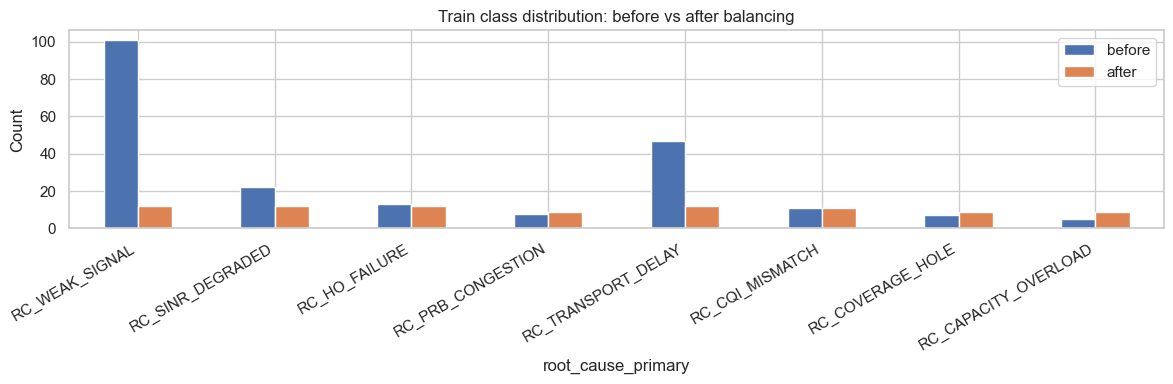

Balanced: 214 -> 86 episodes. Filled 0 missing classes.


In [8]:
# --- 7. Train-Only Class Balancing ---
class_counts = train['root_cause_primary'].value_counts()
target_n = int(max(2, np.ceil(class_counts[class_counts > 0].median()))) if not class_counts.empty else 2
floor_n = int(max(2, np.floor(0.8 * target_n)))

missing_cls = [rc for rc in RC_CLASSES if int(class_counts.get(rc, 0)) == 0]
aug_rows = []
for rc in missing_cls:
    if rc not in train.columns:
        continue
    scores = train[rc].dropna()
    if scores.empty:
        continue
    cut = float(np.nanpercentile(scores, 95))
    cand = train[(train[rc] >= cut) & (train['root_cause_primary'] != rc)].copy()
    cand = cand.sort_values([rc, 'rc_confidence'], ascending=[False, False]).head(target_n)
    if cand.empty:
        continue
    cand['episode_id'] = [f'{eid}__WS_{rc}_{i+1:03d}' for i, eid in enumerate(cand['episode_id'].astype(str))]
    cand['root_cause_primary'] = rc
    cand['root_cause_secondary'] = 'none'
    cand['label_origin'] = 'weak_supervised'
    cand['rc_confidence'] = np.minimum(cand['rc_confidence'], cand[rc]).clip(0, 1)
    cand['sample_weight'] = 0.5
    aug_rows.append(cand)

train_aug = pd.concat([train.assign(sample_weight=1.0)] + aug_rows, ignore_index=True) if aug_rows else train.assign(sample_weight=1.0)

balanced = []
for rc, grp in train_aug.groupby('root_cause_primary'):
    if len(grp) > target_n:
        balanced.append(grp.sample(n=target_n, random_state=SEED))
    elif len(grp) < floor_n and len(grp) > 0:
        extra = grp.sample(n=floor_n - len(grp), replace=True, random_state=SEED)
        balanced.append(pd.concat([grp, extra], ignore_index=True))
    else:
        balanced.append(grp)

train_bal = pd.concat(balanced, ignore_index=True).sort_values('episode_start').reset_index(drop=True)

before_dist = train['root_cause_primary'].value_counts().reindex(RC_CLASSES, fill_value=0)
after_dist = train_bal['root_cause_primary'].value_counts().reindex(RC_CLASSES, fill_value=0)
balance_df = pd.DataFrame({'before': before_dist, 'after': after_dist})

fig, ax = plt.subplots(figsize=(12, 4))
balance_df.plot(kind='bar', ax=ax, title='Train class distribution: before vs after balancing')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(f'Balanced: {len(train)} -> {len(train_bal)} episodes. Filled {len(missing_cls)} missing classes.')

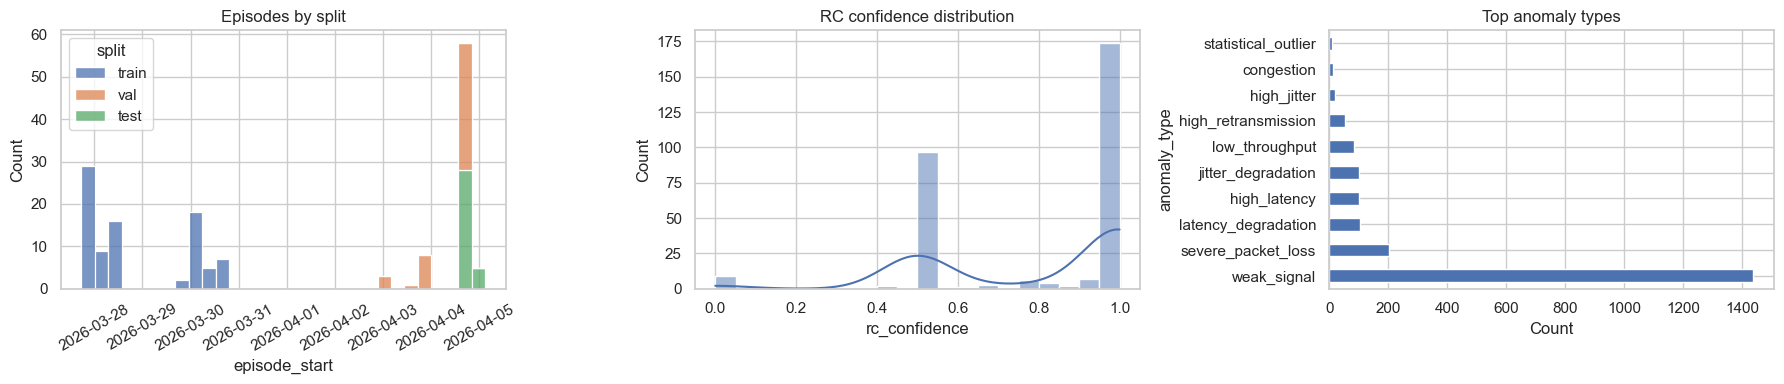

In [9]:
# --- 8. Phase 1 Visual Diagnostics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

split_plot = pd.concat([train_bal.assign(split='train'), val.assign(split='val'), test.assign(split='test')])
sns.histplot(data=split_plot, x='episode_start', hue='split', multiple='stack',
             bins=min(30, max(6, len(split_plot)//2)), ax=axes[0])
axes[0].set_title('Episodes by split')
axes[0].tick_params(axis='x', rotation=30)

sns.histplot(episodes_labeled['rc_confidence'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('RC confidence distribution')

anom_top = qos[qos['anomaly_flag']]['anomaly_type'].value_counts().head(10)
anom_top.plot(kind='barh', ax=axes[2])
axes[2].set_title('Top anomaly types')
axes[2].set_xlabel('Count')
plt.tight_layout()
plt.show()

In [10]:
# --- 9. Phase 1 Summary ---
summary_p1 = {
    'qos_rows': len(qos), 'incident_rows': len(inc), 'episodes': len(episodes_labeled),
    'train': len(train_bal), 'val': len(val), 'test': len(test),
    'rc_classes_active': int((after_dist > 0).sum()), 'rc_classes_total': len(RC_CLASSES),
}
display(pd.DataFrame([summary_p1]).T.rename(columns={0: 'value'}))

go_nogo = 'GO' if (summary_p1['train'] > 0 and summary_p1['val'] > 0 and summary_p1['test'] > 0) else 'NO-GO'
print(f'Phase 1 GO/NO-GO: {go_nogo}')
assert go_nogo == 'GO'
print('Proceeding to Phase 2 bandit benchmark.')

,value
qos_rows,3128
incident_rows,301
episodes,306
train,86
val,42
test,33
rc_classes_active,8
rc_classes_total,8


Phase 1 GO/NO-GO: GO
Proceeding to Phase 2 bandit benchmark.


---
## Phase 2 -- Bandit Policy Benchmark

### Design Principles

1. **Input contract**: Root cause from Diagnostic Agent + KPI context from Phase 1
2. **Action space**: 3 allowed actions per root cause (expanded from 2 for meaningful exploration)
3. **Reward**: Deterministic surrogate with domain-expert action weights (no data leakage)
4. **Evaluation**: Per-episode regret vs oracle, cumulative reward, constraint violations
5. **LLM integration**: Local model (qwen2.5:1.5b) for domain priors -- fast on GTX 1050 + 16 GB RAM

In [11]:
# --- 10. Action Space, Tools & Reward Function ---

ACTIONS = [
    'ACT_ALERT_COVERAGE_HOLE', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_OPTIMIZE_HO_PARAMS',
    'ACT_TRIGGER_CA', 'ACT_REDUCE_BUFFER_SIZE', 'ACT_PRIORITY_VOLTE_SCHEDULING',
    'ACT_RECOMMEND_SITE_ADDITION',
]
N_ACTIONS = len(ACTIONS)

RC_TO_ALLOWED = {
    'RC_WEAK_SIGNAL':       ['ACT_ALERT_COVERAGE_HOLE', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_RECOMMEND_SITE_ADDITION'],
    'RC_SINR_DEGRADED':     ['ACT_TRIGGER_CA', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_OPTIMIZE_HO_PARAMS'],
    'RC_HO_FAILURE':        ['ACT_OPTIMIZE_HO_PARAMS', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_ALERT_COVERAGE_HOLE'],
    'RC_PRB_CONGESTION':    ['ACT_TRIGGER_CA', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_REDUCE_BUFFER_SIZE'],
    'RC_TRANSPORT_DELAY':   ['ACT_REDUCE_BUFFER_SIZE', 'ACT_PRIORITY_VOLTE_SCHEDULING', 'ACT_TRIGGER_CA'],
    'RC_CQI_MISMATCH':     ['ACT_PRIORITY_VOLTE_SCHEDULING', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_TRIGGER_CA'],
    'RC_COVERAGE_HOLE':     ['ACT_RECOMMEND_SITE_ADDITION', 'ACT_ALERT_COVERAGE_HOLE', 'ACT_LOADBALANCE_FREQ_BAND'],
    'RC_CAPACITY_OVERLOAD': ['ACT_TRIGGER_CA', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_RECOMMEND_SITE_ADDITION'],
}

ACTION_RISK = {
    'ACT_ALERT_COVERAGE_HOLE': 'low', 'ACT_LOADBALANCE_FREQ_BAND': 'medium',
    'ACT_OPTIMIZE_HO_PARAMS': 'medium', 'ACT_TRIGGER_CA': 'medium',
    'ACT_REDUCE_BUFFER_SIZE': 'high', 'ACT_PRIORITY_VOLTE_SCHEDULING': 'medium',
    'ACT_RECOMMEND_SITE_ADDITION': 'low',
}
RISK_PENALTY = {'low': 0.0, 'medium': 0.04, 'high': 0.08, 'critical': 0.15}

ACTION_VALUE_WEIGHTS = {
    ('RC_WEAK_SIGNAL',       'ACT_LOADBALANCE_FREQ_BAND'):    0.80,
    ('RC_WEAK_SIGNAL',       'ACT_ALERT_COVERAGE_HOLE'):      0.55,
    ('RC_WEAK_SIGNAL',       'ACT_RECOMMEND_SITE_ADDITION'):  0.65,
    ('RC_SINR_DEGRADED',     'ACT_TRIGGER_CA'):               0.85,
    ('RC_SINR_DEGRADED',     'ACT_LOADBALANCE_FREQ_BAND'):    0.70,
    ('RC_SINR_DEGRADED',     'ACT_OPTIMIZE_HO_PARAMS'):       0.60,
    ('RC_HO_FAILURE',        'ACT_OPTIMIZE_HO_PARAMS'):       0.90,
    ('RC_HO_FAILURE',        'ACT_LOADBALANCE_FREQ_BAND'):    0.50,
    ('RC_HO_FAILURE',        'ACT_ALERT_COVERAGE_HOLE'):      0.40,
    ('RC_PRB_CONGESTION',    'ACT_TRIGGER_CA'):               0.88,
    ('RC_PRB_CONGESTION',    'ACT_LOADBALANCE_FREQ_BAND'):    0.65,
    ('RC_PRB_CONGESTION',    'ACT_REDUCE_BUFFER_SIZE'):       0.55,
    ('RC_TRANSPORT_DELAY',   'ACT_REDUCE_BUFFER_SIZE'):       0.85,
    ('RC_TRANSPORT_DELAY',   'ACT_PRIORITY_VOLTE_SCHEDULING'):0.60,
    ('RC_TRANSPORT_DELAY',   'ACT_TRIGGER_CA'):               0.50,
    ('RC_CQI_MISMATCH',     'ACT_PRIORITY_VOLTE_SCHEDULING'):0.82,
    ('RC_CQI_MISMATCH',     'ACT_LOADBALANCE_FREQ_BAND'):    0.58,
    ('RC_CQI_MISMATCH',     'ACT_TRIGGER_CA'):               0.50,
    ('RC_COVERAGE_HOLE',     'ACT_RECOMMEND_SITE_ADDITION'):  0.90,
    ('RC_COVERAGE_HOLE',     'ACT_ALERT_COVERAGE_HOLE'):      0.70,
    ('RC_COVERAGE_HOLE',     'ACT_LOADBALANCE_FREQ_BAND'):    0.45,
    ('RC_CAPACITY_OVERLOAD', 'ACT_TRIGGER_CA'):               0.85,
    ('RC_CAPACITY_OVERLOAD', 'ACT_LOADBALANCE_FREQ_BAND'):    0.70,
    ('RC_CAPACITY_OVERLOAD', 'ACT_RECOMMEND_SITE_ADDITION'):  0.55,
}

APPROVED_TOOLS = [
    'PRECHECK_CONFIG', 'ROLLBACK_PLAN', 'CAPACITY_CHECK', 'NEIGHBOR_INTERFERENCE_CHECK',
    'HO_GUARDRAIL_CHECK', 'SITE_IMPACT_ASSESSMENT', 'LATENCY_SAFETY_CHECK',
    'QOS_POLICY_CONFLICT_CHECK', 'TICKET_CREATE', 'CAPEX_WORKFLOW_CHECK',
    'HUMAN_APPROVAL', 'CHANGE_WINDOW_CHECK',
]
RISK_MANDATORY_TOOLS = {
    'low':     ['PRECHECK_CONFIG'],
    'medium':  ['PRECHECK_CONFIG', 'ROLLBACK_PLAN'],
    'high':    ['PRECHECK_CONFIG', 'ROLLBACK_PLAN', 'CAPACITY_CHECK'],
    'critical':['PRECHECK_CONFIG', 'ROLLBACK_PLAN', 'CAPACITY_CHECK', 'HUMAN_APPROVAL'],
}
ACTION_TOOLS = {
    'ACT_ALERT_COVERAGE_HOLE':       ['TICKET_CREATE', 'SITE_IMPACT_ASSESSMENT'],
    'ACT_LOADBALANCE_FREQ_BAND':     ['NEIGHBOR_INTERFERENCE_CHECK', 'CHANGE_WINDOW_CHECK'],
    'ACT_OPTIMIZE_HO_PARAMS':        ['HO_GUARDRAIL_CHECK', 'CHANGE_WINDOW_CHECK'],
    'ACT_TRIGGER_CA':                ['CAPACITY_CHECK', 'NEIGHBOR_INTERFERENCE_CHECK'],
    'ACT_REDUCE_BUFFER_SIZE':        ['LATENCY_SAFETY_CHECK', 'CHANGE_WINDOW_CHECK'],
    'ACT_PRIORITY_VOLTE_SCHEDULING': ['QOS_POLICY_CONFLICT_CHECK'],
    'ACT_RECOMMEND_SITE_ADDITION':   ['CAPEX_WORKFLOW_CHECK', 'SITE_IMPACT_ASSESSMENT'],
}

def reward_surrogate(row, action):
    rc = row['root_cause_primary']
    w = ACTION_VALUE_WEIGHTS.get((rc, action), 0.3)
    rc_str = float(row.get(rc, 0.0)) if rc in row.index else 0.0
    sev = float(row.get('severity_proxy', 0.5))
    base = w * (0.5 + 0.5 * rc_str)
    penalty = RISK_PENALTY.get(ACTION_RISK.get(action, 'medium'), 0.04) * sev
    conf_scale = 0.6 + 0.4 * float(row.get('rc_confidence', 0.5))
    return float(np.clip((base - penalty) * conf_scale, 0.0, 1.0))

def oracle_action(row):
    allowed = row['allowed_actions']
    rewards = {a: reward_surrogate(row, a) for a in allowed}
    best = max(rewards, key=rewards.get)
    return best, rewards[best]

rc_df = pd.DataFrame([
    {'root_cause': rc, 'action': a, 'weight': ACTION_VALUE_WEIGHTS.get((rc, a), 0),
     'risk': ACTION_RISK.get(a, '?'), 'tools': ', '.join(ACTION_TOOLS.get(a, []))}
    for rc, acts in RC_TO_ALLOWED.items() for a in acts
])
print(f'Action space: {N_ACTIONS} actions, 3 per RC, {len(ACTION_VALUE_WEIGHTS)} weighted pairs')
display(rc_df)

Action space: 7 actions, 3 per RC, 24 weighted pairs


,root_cause,action,weight,risk,tools
0,RC_WEAK_SIGNAL,ACT_ALERT_COVERAGE_HOLE,0.55,low,"TICKET_CREATE, SITE_IMPACT_ASSESSMENT"
1,RC_WEAK_SIGNAL,ACT_LOADBALANCE_FREQ_BAND,0.80,medium,"NEIGHBOR_INTERFERENCE_CHECK, CHANGE_WINDOW_CHECK"
2,RC_WEAK_SIGNAL,ACT_RECOMMEND_SITE_ADDITION,0.65,low,"CAPEX_WORKFLOW_CHECK, SITE_IMPACT_ASSESSMENT"
3,RC_SINR_DEGRADED,ACT_TRIGGER_CA,0.85,medium,"CAPACITY_CHECK, NEIGHBOR_INTERFERENCE_CHECK"
4,RC_SINR_DEGRADED,ACT_LOADBALANCE_FREQ_BAND,0.70,medium,"NEIGHBOR_INTERFERENCE_CHECK, CHANGE_WINDOW_CHECK"
5,RC_SINR_DEGRADED,ACT_OPTIMIZE_HO_PARAMS,0.60,medium,"HO_GUARDRAIL_CHECK, CHANGE_WINDOW_CHECK"
6,RC_HO_FAILURE,ACT_OPTIMIZE_HO_PARAMS,0.90,medium,"HO_GUARDRAIL_CHECK, CHANGE_WINDOW_CHECK"
7,RC_HO_FAILURE,ACT_LOADBALANCE_FREQ_BAND,0.50,medium,"NEIGHBOR_INTERFERENCE_CHECK, CHANGE_WINDOW_CHECK"
8,RC_HO_FAILURE,ACT_ALERT_COVERAGE_HOLE,0.40,low,"TICKET_CREATE, SITE_IMPACT_ASSESSMENT"
9,RC_PRB_CONGESTION,ACT_TRIGGER_CA,0.88,medium,"CAPACITY_CHECK, NEIGHBOR_INTERFERENCE_CHECK"


In [12]:
# --- 11. Tool Execution Engine (Deterministic Simulation) ---
import datetime as _dt

def execute_tool(tool_name, action, ctx):
    sev = float(ctx.get('severity_proxy', 0.5))
    rc_conf = float(ctx.get('rc_confidence', 0.5))
    dur = float(ctx.get('duration_sec', 60.0))
    impls = {
        'PRECHECK_CONFIG': lambda: {'config_version': 'v3.1', 'conflicts': [], 'safe': True},
        'ROLLBACK_PLAN': lambda: {'window_min': 30, 'steps': ['snapshot', 'restore'], 'ready': True},
        'CAPACITY_CHECK': lambda: {'prb_util_pct': round(min(95, 50+sev*45),1), 'headroom_pct': round(max(5, 50-sev*45),1)},
        'NEIGHBOR_INTERFERENCE_CHECK': lambda: {'interfering_cells': int(sev*3), 'rsrp_delta_db': round(sev*8,1)},
        'HO_GUARDRAIL_CHECK': lambda: {'ho_success_pct': round(100-sev*40,1), 'ok': sev<0.8},
        'SITE_IMPACT_ASSESSMENT': lambda: {'affected_nodes': int(1+sev*4), 'impact': 'minor' if sev<0.5 else 'moderate'},
        'LATENCY_SAFETY_CHECK': lambda: {'buffer_ms': round(20+sev*80,1), 'ok': sev<0.7},
        'QOS_POLICY_CONFLICT_CHECK': lambda: {'volte_ok': True, 'safe': rc_conf>0.5},
        'TICKET_CREATE': lambda: {'ticket_id': f'NOC-{int(dur*7%9999):04d}', 'priority': 'P1' if sev>0.7 else 'P2'},
        'CAPEX_WORKFLOW_CHECK': lambda: {'budget_ok': True, 'lead_weeks': 12},
        'HUMAN_APPROVAL': lambda: {'approver': 'NOC_supervisor', 'wait_min': 15 if sev>0.7 else 30},
        'CHANGE_WINDOW_CHECK': lambda: {'window': 'maintenance', 'proceed': True},
    }
    impl = impls.get(tool_name, lambda: {'result': 'unknown_tool'})
    try:
        return {'tool': tool_name, 'status': 'ok', 'result': impl()}
    except Exception as ex:
        return {'tool': tool_name, 'status': 'error', 'error': str(ex)}

def run_tools_for_action(action, ctx):
    risk = ACTION_RISK.get(action, 'medium')
    tool_list = list(dict.fromkeys(RISK_MANDATORY_TOOLS.get(risk, ['PRECHECK_CONFIG']) + ACTION_TOOLS.get(action, [])))
    return [execute_tool(t, action, ctx) for t in tool_list]

test_tools = run_tools_for_action('ACT_TRIGGER_CA', {'severity_proxy': 0.6, 'rc_confidence': 0.8, 'duration_sec': 120})
print(f'Tool test: {len(test_tools)} tools for ACT_TRIGGER_CA')
for t in test_tools:
    print(f"  {t['tool']}: {t['status']}")

Tool test: 4 tools for ACT_TRIGGER_CA
  PRECHECK_CONFIG: ok
  ROLLBACK_PLAN: ok
  CAPACITY_CHECK: ok
  NEIGHBOR_INTERFERENCE_CHECK: ok


In [13]:
# --- 12. Build Phase 2 Context ---
kpi_agg_cols = ['latency_ms', 'jitter_ms', 'packet_loss_pct', 'throughput_mbps',
                'sinr_db', 'rsrp_dbm', 'cqi', 'bandwidth_util_pct']

def compute_kpi_aggs(ep_row):
    g = qos[(qos['node_id']==ep_row['node_id']) &
            (qos['timestamp']>=ep_row['episode_start']) &
            (qos['timestamp']<=ep_row['episode_end'])]
    aggs = {}
    for col in kpi_agg_cols:
        if col in g.columns:
            vals = pd.to_numeric(g[col], errors='coerce').dropna()
            aggs[f'{col}_mean'] = float(vals.mean()) if len(vals) > 0 else 0.0
            aggs[f'{col}_std'] = float(vals.std()) if len(vals) > 1 else 0.0
        else:
            aggs[f'{col}_mean'] = 0.0
            aggs[f'{col}_std'] = 0.0
    return aggs

for frame in [train_bal, val, test]:
    kpi_rows = [compute_kpi_aggs(row) for _, row in frame.iterrows()]
    kpi_df_tmp = pd.DataFrame(kpi_rows)
    for c in kpi_df_tmp.columns:
        frame[c] = kpi_df_tmp[c].values

DUR_SCALE = float(max(np.nanpercentile(train_bal['duration_sec'], 95), 1.0))

def build_phase2(frame, split_name):
    out = frame.copy()
    out['split'] = split_name
    out['allowed_actions'] = out['root_cause_primary'].map(RC_TO_ALLOWED)
    out['preferred_action'] = out['root_cause_primary'].map(
        lambda rc: max(RC_TO_ALLOWED[rc], key=lambda a: ACTION_VALUE_WEIGHTS.get((rc, a), 0.0)))
    dur_share = (out['duration_sec'].fillna(0) / DUR_SCALE).clip(0, 1)
    out['severity_proxy'] = (0.55 * out['rc_confidence'].fillna(0) + 0.45 * dur_share).clip(0, 1)
    return out

phase2 = pd.concat([build_phase2(train_bal, 'train'), build_phase2(val, 'val'), build_phase2(test, 'test')], ignore_index=True)
assert phase2['allowed_actions'].notna().all()

feature_cols = (['rc_confidence', 'duration_sec', 'qos_rows'] + RC_CLASSES +
                [f'{c}_mean' for c in kpi_agg_cols] + [f'{c}_std' for c in kpi_agg_cols])

train_df = phase2[phase2['split']=='train'].reset_index(drop=True)
val_df   = phase2[phase2['split']=='val'].reset_index(drop=True)
test_df  = phase2[phase2['split']=='test'].reset_index(drop=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols].fillna(0).to_numpy(dtype=float))
X_val   = scaler.transform(val_df[feature_cols].fillna(0).to_numpy(dtype=float))
X_test  = scaler.transform(test_df[feature_cols].fillna(0).to_numpy(dtype=float))

n_features = X_train.shape[1]
print(f'Phase 2 ready: {len(train_df)} train / {len(val_df)} val / {len(test_df)} test')
print(f'Features: {n_features} (3 base + {len(RC_CLASSES)} RC + {len(kpi_agg_cols)*2} KPI aggs)')

Phase 2 ready: 86 train / 42 val / 33 test
Features: 27 (3 base + 8 RC + 16 KPI aggs)


In [14]:
# --- 13. Model 1: LinUCB (Disjoint) ---

class LinUCB:
    def __init__(self, actions, d, alpha=1.0):
        self.actions = actions
        self.d = d
        self.alpha = alpha
        self.A = {a: np.eye(d) for a in actions}
        self.b = {a: np.zeros(d) for a in actions}

    def select(self, x, allowed):
        scores = {}
        for a in allowed:
            A_inv = np.linalg.solve(self.A[a], np.eye(self.d))
            theta = A_inv @ self.b[a]
            ucb = float(x @ theta + self.alpha * np.sqrt(x @ A_inv @ x))
            scores[a] = ucb
        return max(scores, key=scores.get), scores

    def update(self, x, action, reward):
        self.A[action] += np.outer(x, x)
        self.b[action] += reward * x

LINUCB_ALPHA = 0.8
vanilla = LinUCB(ACTIONS, n_features, alpha=LINUCB_ALPHA)
print(f'LinUCB initialized: {N_ACTIONS} arms, d={n_features}, alpha={LINUCB_ALPHA}')

LinUCB initialized: 7 arms, d=27, alpha=0.8


In [15]:
# --- 14. Model 2: Neural Thompson Sampling ---

class NeuralTS:
    def __init__(self, actions, x_dim, n_models=5, hidden=(64, 32), random_state=42):
        self.actions = actions
        self.x_dim = x_dim
        self.n_models = n_models
        self.rng = np.random.default_rng(random_state)
        self.models = [
            MLPRegressor(hidden_layer_sizes=hidden, max_iter=500, random_state=random_state+i,
                         early_stopping=True, validation_fraction=0.15, n_iter_no_change=10,
                         learning_rate='adaptive', learning_rate_init=0.001)
            for i in range(n_models)
        ]
        self.scaler = StandardScaler()
        self.is_fit = False

    def _joint(self, X, a_idx):
        n = X.shape[0]
        A_oh = np.zeros((n, len(self.actions)))
        A_oh[np.arange(n), a_idx] = 1.0
        return np.hstack([X, A_oh])

    def fit(self, X, a_idx, y):
        Z = self._joint(X, a_idx)
        Zs = self.scaler.fit_transform(Z)
        rng = np.random.default_rng(42)
        n = len(y)
        for m in self.models:
            ids = rng.integers(0, n, size=n)
            m.fit(Zs[ids], y[ids])
        self.is_fit = True
        print(f'  Fitted {self.n_models} bootstrap models on {n} samples')

    def select(self, x, allowed):
        m = self.models[self.rng.integers(0, self.n_models)]
        scores = {}
        for a in allowed:
            a_idx = self.actions.index(a)
            z = np.concatenate([x, np.eye(len(self.actions))[a_idx]])
            zs = self.scaler.transform(z.reshape(1, -1))
            scores[a] = float(m.predict(zs)[0])
        return max(scores, key=scores.get), scores

Xr, ar, yr = [], [], []
for i in range(len(train_df)):
    row = train_df.iloc[i]
    x = X_train[i]
    for a in row['allowed_actions']:
        Xr.append(x)
        ar.append(ACTIONS.index(a))
        yr.append(reward_surrogate(row, a))

Xr = np.array(Xr, dtype=np.float64)
ar = np.array(ar, dtype=np.int32)
yr = np.array(yr, dtype=np.float64)

print(f'Training Neural TS on {len(yr)} tuples...')
neural_ts = NeuralTS(ACTIONS, n_features, n_models=5, hidden=(64, 32), random_state=SEED)
neural_ts.fit(Xr, ar, yr)

test_act, test_scores = neural_ts.select(X_train[0], train_df.iloc[0]['allowed_actions'])
print(f'Sanity: selected {test_act}')

Training Neural TS on 258 tuples...


  Fitted 5 bootstrap models on 258 samples
Sanity: selected ACT_RECOMMEND_SITE_ADDITION


In [16]:
# --- 15. Model 3: LLM-Guided LinUCB ---

OLLAMA_URL = 'http://localhost:11434/api/generate'
OLLAMA_TAGS_URL = 'http://localhost:11434/api/tags'
# Preference order: small first (fast on GTX 1050 / 4 GB VRAM), larger as fallback.
OLLAMA_MODEL_PREFERENCES = ['qwen2.5:1.5b', 'qwen2.5:3b', 'phi3:mini', 'qwen2:7b']
OLLAMA_TIMEOUT = 90
LLM_GAMMA = 0.6

def _pick_ollama_model():
    try:
        import requests
        r = requests.get(OLLAMA_TAGS_URL, timeout=3)
        if r.status_code != 200:
            return None
        installed = {m.get('name', '') for m in r.json().get('models', [])}
        for pref in OLLAMA_MODEL_PREFERENCES:
            if pref in installed:
                return pref
        # last resort: first installed model
        return next(iter(installed), None)
    except Exception:
        return None

OLLAMA_MODEL = _pick_ollama_model()
print(f'Selected Ollama model: {OLLAMA_MODEL}')

LLM_PROMPT = (
    'You are a telecom QoS optimization advisor. '
    'Given a root cause and allowed actions, score each action.\n\n'
    'Return ONLY valid JSON:\n'
    '{"priors": {"ACTION_NAME": <float 0-1>, ...}, '
    '"chosen_arm": "BEST_ACTION", '
    '"reasoning": "one sentence why"}\n\n'
    'Rules: priors must score EVERY allowed action. '
    'chosen_arm must be one of allowed_actions. '
    'Higher prior = better expected outcome.'
)

LLM_CACHE = {}
LLM_CALL_COUNT = 0

def _ollama_call(prompt):
    global LLM_CALL_COUNT
    LLM_CALL_COUNT += 1
    if not OLLAMA_MODEL:
        return '', False
    try:
        import requests
        resp = requests.post(OLLAMA_URL, json={
            'model': OLLAMA_MODEL, 'prompt': prompt, 'stream': False,
            'options': {'temperature': 0.0, 'num_ctx': 512, 'num_predict': 256}
        }, timeout=OLLAMA_TIMEOUT)
        if resp.status_code == 200:
            return resp.json().get('response', ''), True
        return '', False
    except Exception:
        return '', False

def _parse_llm(text, allowed):
    text = text.strip()
    if '```' in text:
        for p in text.split('```'):
            p = p.strip()
            if p.startswith('json'):
                p = p[4:].strip()
            if p.startswith('{'):
                text = p
                break
    try:
        obj = json.loads(text)
    except json.JSONDecodeError:
        s, e = text.find('{'), text.rfind('}')
        if s >= 0 and e > s:
            try:
                obj = json.loads(text[s:e+1])
            except json.JSONDecodeError:
                return None
        else:
            return None
    if not isinstance(obj, dict):
        return None
    priors = obj.get('priors', {})
    chosen = obj.get('chosen_arm', '')
    if not isinstance(priors, dict) or chosen not in allowed:
        return None
    for a in allowed:
        if a not in priors:
            priors[a] = 0.5
    return {'priors': priors, 'chosen_arm': chosen, 'reasoning': obj.get('reasoning', '')}

def get_llm_priors(rc, allowed, ctx):
    cache_key = rc + '|' + '|'.join(sorted(allowed))
    if cache_key in LLM_CACHE:
        return LLM_CACHE[cache_key]

    rc_c = ctx.get('rc_confidence', 0.5)
    sev_v = ctx.get('severity_proxy', 0.5)
    prompt = (LLM_PROMPT + '\n\n'
              + 'Root cause: ' + rc + '\n'
              + 'Allowed actions: ' + json.dumps(allowed) + '\n'
              + f'Context: rc_confidence={rc_c:.2f}, severity={sev_v:.2f}')

    text, ok = _ollama_call(prompt)
    if ok:
        parsed = _parse_llm(text, allowed)
        if parsed:
            raw = np.array([float(parsed['priors'].get(a, 0.5)) for a in allowed])
            normed = scipy_softmax(raw)
            result = {'priors': {a: float(normed[i]) for i, a in enumerate(allowed)},
                      'chosen_arm': parsed['chosen_arm'], 'reasoning': parsed.get('reasoning', ''), 'ok': True}
            LLM_CACHE[cache_key] = result
            return result

    uniform = {a: 1.0 / len(allowed) for a in allowed}
    result = {'priors': uniform, 'chosen_arm': allowed[0], 'reasoning': 'fallback', 'ok': False}
    LLM_CACHE[cache_key] = result
    return result

class LLMGuidedLinUCB:
    def __init__(self, actions, d, alpha=0.8, gamma=0.6):
        self.linucb = LinUCB(actions, d, alpha)
        self.gamma = gamma
        self.actions = actions

    def select(self, x, allowed, rc, ctx):
        _, ucb_scores = self.linucb.select(x, allowed)
        llm_result = get_llm_priors(rc, allowed, ctx)
        fused = {a: ucb_scores.get(a, 0) + self.gamma * llm_result['priors'].get(a, 0) for a in allowed}
        return max(fused, key=fused.get), {'ucb': ucb_scores, 'llm': llm_result['priors'], 'fused': fused, 'llm_ok': llm_result['ok']}

    def update(self, x, action, reward):
        self.linucb.update(x, action, reward)

llm_ucb = LLMGuidedLinUCB(ACTIONS, n_features, alpha=LINUCB_ALPHA, gamma=LLM_GAMMA)

print('Testing LLM connection...')
test_llm = get_llm_priors('RC_WEAK_SIGNAL',
    ['ACT_ALERT_COVERAGE_HOLE', 'ACT_LOADBALANCE_FREQ_BAND', 'ACT_RECOMMEND_SITE_ADDITION'],
    {'rc_confidence': 0.8, 'severity_proxy': 0.5})
llm_available = test_llm['ok']
print(f'LLM available: {llm_available}')
if llm_available:
    print(f'  Priors: {test_llm["priors"]}')
    print(f'  Chosen: {test_llm["chosen_arm"]}')
else:
    print('  LLM not reachable -- using uniform fallback priors.')
    print('  To enable: install Ollama, then `ollama pull qwen2.5:1.5b && ollama serve`')

Selected Ollama model: qwen2:7b
Testing LLM connection...


LLM available: True
  Priors: {'ACT_ALERT_COVERAGE_HOLE': 0.4260125149492057, 'ACT_LOADBALANCE_FREQ_BAND': 0.3155978333128143, 'ACT_RECOMMEND_SITE_ADDITION': 0.25838965173797984}
  Chosen: ACT_ALERT_COVERAGE_HOLE


In [17]:
# --- 16. Policy & Safety Gate ---

class PolicyGate:
    MODES = ['recommendation_only', 'semi_automatic', 'controlled_autonomy']

    def __init__(self, mode='semi_automatic'):
        assert mode in self.MODES
        self.mode = mode

    def evaluate(self, action, ctx):
        risk = ACTION_RISK.get(action, 'high')
        sev = float(ctx.get('severity_proxy', 0.5))
        checks = {
            'risk_acceptable': risk in ('low', 'medium') or sev < 0.7,
            'impact_bounded': True,
            'change_window_ok': True,
            'rollback_available': risk != 'critical',
            'regulatory_ok': True,
            'resource_ok': sev < 0.9,
        }
        all_pass = all(checks.values())
        if self.mode == 'recommendation_only':
            outcome = 'PENDING_APPROVAL'
        elif self.mode == 'semi_automatic':
            if all_pass and risk in ('low', 'medium'):
                outcome = 'APPROVED'
            elif not all_pass:
                outcome = 'REJECTED'
            else:
                outcome = 'PENDING_APPROVAL'
        else:
            outcome = 'APPROVED' if all_pass else 'PENDING_APPROVAL'
        return {'action': action, 'outcome': outcome, 'risk': risk, 'checks': checks, 'all_pass': all_pass}

gate_engine = PolicyGate(mode='semi_automatic')
for act in ['ACT_ALERT_COVERAGE_HOLE', 'ACT_REDUCE_BUFFER_SIZE', 'ACT_TRIGGER_CA']:
    r = gate_engine.evaluate(act, {'severity_proxy': 0.6, 'rc_confidence': 0.8})
    print(f"{act}: {r['outcome']} (risk={r['risk']})")

ACT_ALERT_COVERAGE_HOLE: APPROVED (risk=low)
ACT_REDUCE_BUFFER_SIZE: PENDING_APPROVAL (risk=high)
ACT_TRIGGER_CA: APPROVED (risk=medium)


In [18]:
# --- 17. Evaluation Framework ---

def evaluate_policy(name, policy, frame, X, use_llm=False):
    eval_rows = []
    cumulative_rewards = []
    cum_r = 0.0

    for j in range(len(frame)):
        row = frame.iloc[j]
        x = X[j]
        rc = row['root_cause_primary']
        allowed = row['allowed_actions']

        if name == 'LLM_Guided_LinUCB':
            ctx = {'rc_confidence': float(row['rc_confidence']), 'severity_proxy': float(row['severity_proxy'])}
            action, info = policy.select(x, allowed, rc, ctx)
            llm_ok = info.get('llm_ok', False)
        else:
            action, info = policy.select(x, allowed)
            llm_ok = False

        reward = reward_surrogate(row, action)
        ora_act, ora_rew = oracle_action(row)

        tool_ctx = {'severity_proxy': float(row.get('severity_proxy', 0.5)),
                    'rc_confidence': float(row.get('rc_confidence', 0.5)),
                    'duration_sec': float(row.get('duration_sec', 60))}
        tools = run_tools_for_action(action, tool_ctx)
        gate_result = gate_engine.evaluate(action, tool_ctx)

        cum_r += reward
        cumulative_rewards.append(cum_r)

        eval_rows.append({
            'policy': name, 'split': row['split'], 'step': j,
            'episode_id': row['episode_id'], 'root_cause': rc,
            'action': action, 'reward': reward,
            'oracle_action': ora_act, 'oracle_reward': ora_rew,
            'regret': ora_rew - reward, 'oracle_match': int(action == ora_act),
            'constraint_violation': int(action not in allowed),
            'gate_outcome': gate_result['outcome'], 'llm_ok': llm_ok, 'n_tools': len(tools),
        })

        if hasattr(policy, 'update'):
            policy.update(x, action, reward)
        elif hasattr(policy, 'linucb'):
            policy.linucb.update(x, action, reward)

    return pd.DataFrame(eval_rows), cumulative_rewards

print('Evaluation framework ready.')

Evaluation framework ready.


In [19]:
# --- 18. Run All Evaluations ---

vanilla = LinUCB(ACTIONS, n_features, alpha=LINUCB_ALPHA)
llm_ucb = LLMGuidedLinUCB(ACTIONS, n_features, alpha=LINUCB_ALPHA, gamma=LLM_GAMMA)
LLM_CACHE.clear()
LLM_CALL_COUNT = 0

policies = [
    ('LinUCB', vanilla, False),
    ('Neural_TS', neural_ts, False),
    ('LLM_Guided_LinUCB', llm_ucb, True),
]

all_eval = []
cumulative = {}

for name, policy, use_llm in policies:
    print(f'\n{"="*60}\nEvaluating: {name}\n{"="*60}')
    for sn, sf, sx in [('train', train_df, X_train), ('val', val_df, X_val), ('test', test_df, X_test)]:
        t0 = time.time()
        edf, cum = evaluate_policy(name, policy, sf, sx, use_llm)
        elapsed = time.time() - t0
        all_eval.append(edf)
        cumulative[(name, sn)] = cum
        print(f'  {sn:5s}: n={len(edf):4d} | reward={edf["reward"].mean():.4f} | '
              f'regret={edf["regret"].mean():.4f} | oracle={edf["oracle_match"].mean():.2%} | {elapsed:.1f}s')

eval_all = pd.concat(all_eval, ignore_index=True)
print(f'\nTotal evaluations: {len(eval_all)}, LLM calls: {LLM_CALL_COUNT}')


Evaluating: LinUCB
  train: n=  86 | reward=0.5763 | regret=0.1227 | oracle=44.19% | 0.1s


  val  : n=  42 | reward=0.6393 | regret=0.1107 | oracle=50.00% | 0.0s
  test : n=  33 | reward=0.6015 | regret=0.1315 | oracle=39.39% | 0.0s

Evaluating: Neural_TS


  train: n=  86 | reward=0.6637 | regret=0.0353 | oracle=81.40% | 0.2s


  val  : n=  42 | reward=0.6186 | regret=0.1314 | oracle=38.10% | 0.1s


  test : n=  33 | reward=0.6206 | regret=0.1124 | oracle=39.39% | 0.1s

Evaluating: LLM_Guided_LinUCB


  train: n=  86 | reward=0.5947 | regret=0.1044 | oracle=48.84% | 293.3s
  val  : n=  42 | reward=0.6190 | regret=0.1310 | oracle=42.86% | 0.0s
  test : n=  33 | reward=0.6602 | regret=0.0728 | oracle=60.61% | 0.0s

Total evaluations: 483, LLM calls: 8


In [20]:
# --- 19. Results Summary ---

summary_p2 = (eval_all.groupby(['policy', 'split'])
              .agg(n=('reward', 'size'), avg_reward=('reward', 'mean'), std_reward=('reward', 'std'),
                   avg_regret=('regret', 'mean'), oracle_rate=('oracle_match', 'mean'),
                   violations=('constraint_violation', 'sum'))
              .reset_index())

print('='*80)
print('BENCHMARK RESULTS')
print('='*80)
display(summary_p2)

test_rank = summary_p2[summary_p2['split']=='test'].sort_values('avg_reward', ascending=False)
print('\n--- Test Set Ranking ---')
for _, r in test_rank.iterrows():
    print(f"  {r['policy']:25s} | reward={r['avg_reward']:.4f} | regret={r['avg_regret']:.4f} | oracle={r['oracle_rate']:.2%}")

best = test_rank.iloc[0]
print(f"\nBest on test: {best['policy']} (reward={best['avg_reward']:.4f})")

BENCHMARK RESULTS


,policy,split,n,avg_reward,std_reward,avg_regret,oracle_rate,violations
0,LLM_Guided_LinUCB,test,33,0.660162,0.144138,0.072819,0.606061,0
1,LLM_Guided_LinUCB,train,86,0.594666,0.197343,0.104370,0.488372,0
2,LLM_Guided_LinUCB,val,42,0.619006,0.163359,0.130955,0.428571,0
3,LinUCB,test,33,0.601470,0.149884,0.131511,0.393939,0
4,LinUCB,train,86,0.576308,0.202683,0.122728,0.441860,0
5,LinUCB,val,42,0.639260,0.168474,0.110701,0.500000,0
6,Neural_TS,test,33,0.620576,0.163152,0.112405,0.393939,0
7,Neural_TS,train,86,0.663738,0.186003,0.035298,0.813953,0
8,Neural_TS,val,42,0.618551,0.153744,0.131410,0.380952,0



--- Test Set Ranking ---
  LLM_Guided_LinUCB         | reward=0.6602 | regret=0.0728 | oracle=60.61%
  Neural_TS                 | reward=0.6206 | regret=0.1124 | oracle=39.39%
  LinUCB                    | reward=0.6015 | regret=0.1315 | oracle=39.39%

Best on test: LLM_Guided_LinUCB (reward=0.6602)


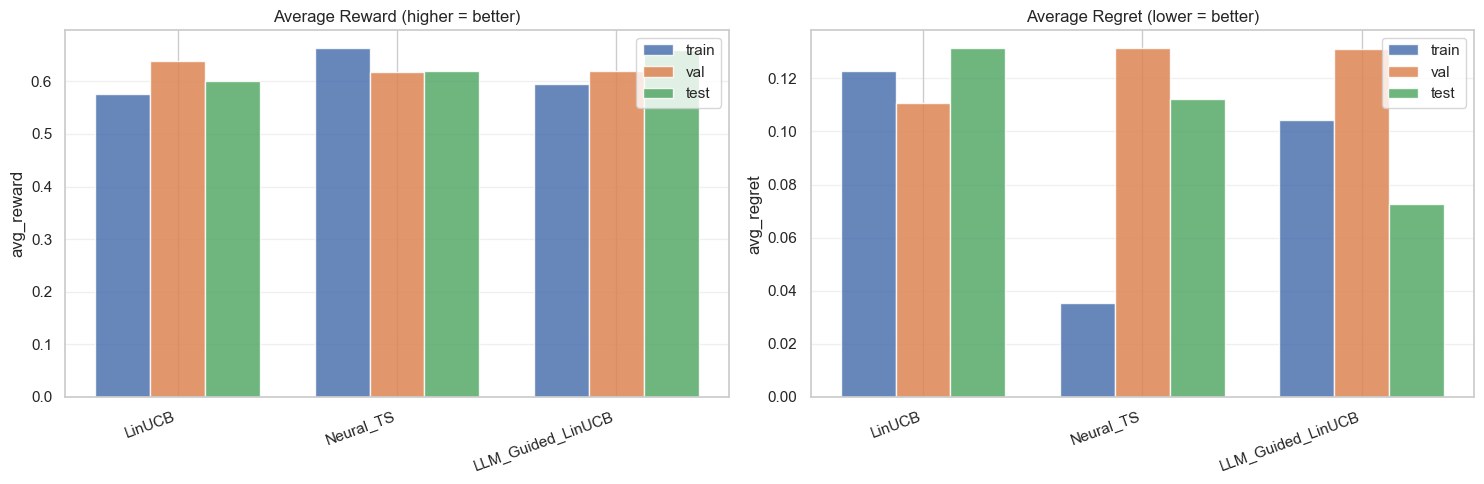

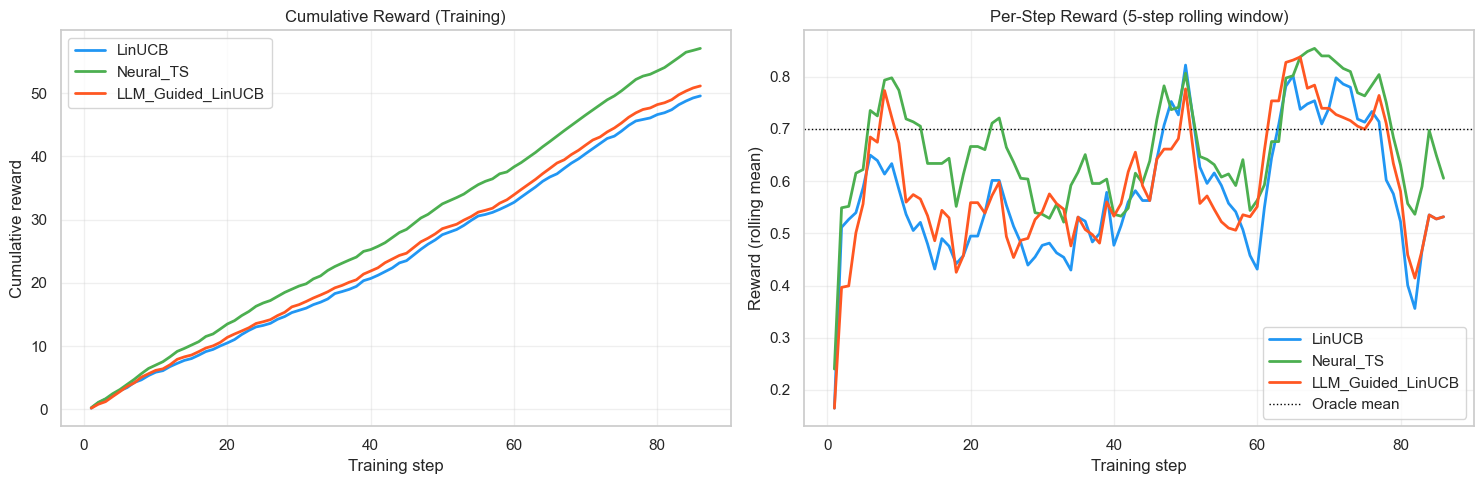

In [21]:
# --- 20. Visualizations ---
palette = {'LinUCB': '#2196F3', 'Neural_TS': '#4CAF50', 'LLM_Guided_LinUCB': '#FF5722'}
policy_names = ['LinUCB', 'Neural_TS', 'LLM_Guided_LinUCB']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(axes, ['avg_reward', 'avg_regret'],
    ['Average Reward (higher = better)', 'Average Regret (lower = better)']):
    x = np.arange(len(policy_names))
    width = 0.25
    for k, split in enumerate(['train', 'val', 'test']):
        sub = summary_p2[summary_p2['split']==split]
        vals = [float(sub[sub['policy']==p][metric].values[0]) if len(sub[sub['policy']==p]) > 0 else 0
                for p in policy_names]
        ax.bar(x + k*width - width, vals, width, label=split, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(policy_names, rotation=20, ha='right')
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name in policy_names:
    key = (name, 'train')
    if key in cumulative:
        cum = cumulative[key]
        axes[0].plot(range(1, len(cum)+1), cum, label=name, color=palette.get(name), lw=2)
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Cumulative reward')
axes[0].set_title('Cumulative Reward (Training)')
axes[0].legend()
axes[0].grid(alpha=0.3)

window = max(3, len(train_df) // 15)
for name in policy_names:
    key = (name, 'train')
    if key in cumulative:
        cum = cumulative[key]
        per_step = [cum[0]] + [cum[i] - cum[i-1] for i in range(1, len(cum))]
        rolling = pd.Series(per_step).rolling(window, min_periods=1).mean()
        axes[1].plot(range(1, len(rolling)+1), rolling, label=name, color=palette.get(name), lw=2)

train_oracle_mean = eval_all[eval_all['split']=='train']['oracle_reward'].mean()
axes[1].axhline(train_oracle_mean, color='black', ls=':', lw=1, label='Oracle mean')
axes[1].set_xlabel('Training step')
axes[1].set_ylabel('Reward (rolling mean)')
axes[1].set_title(f'Per-Step Reward ({window}-step rolling window)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

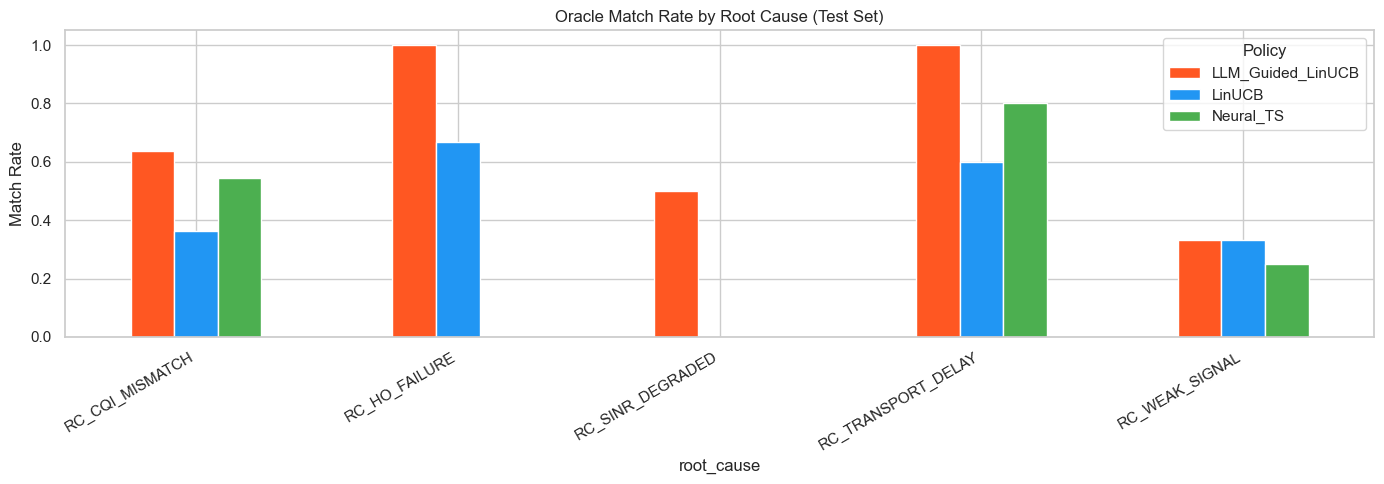

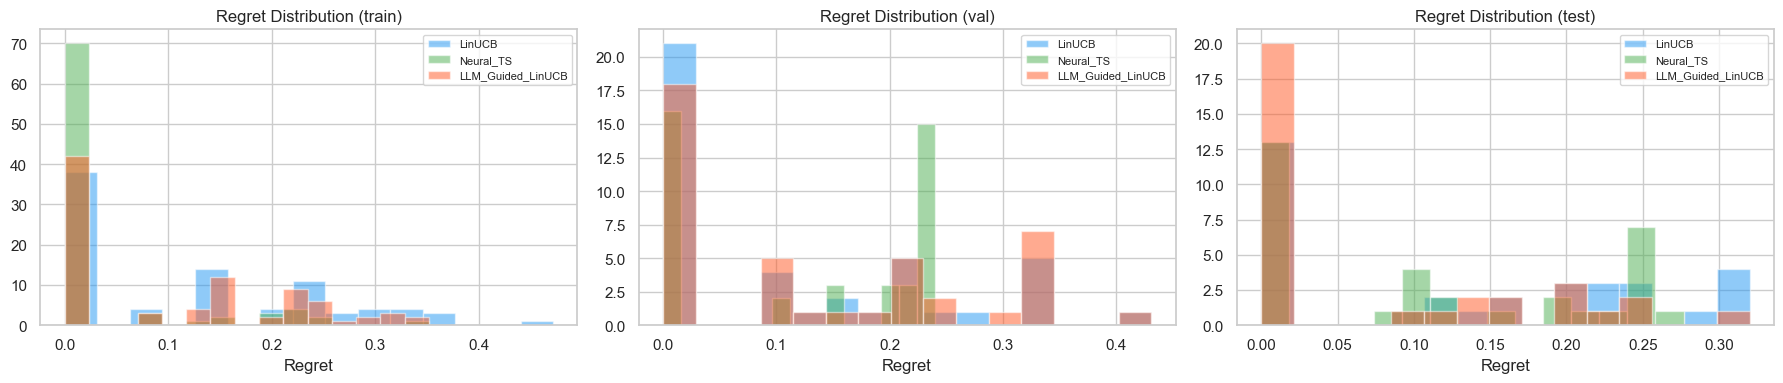

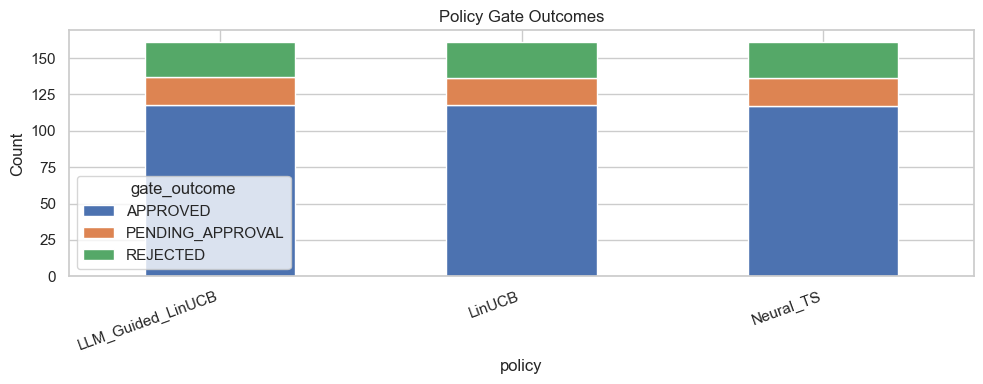

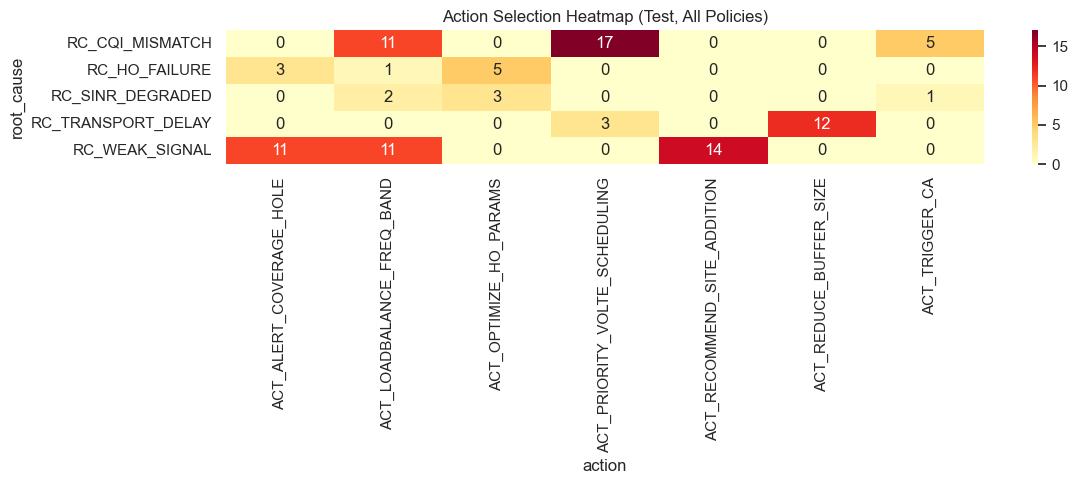

In [22]:
# --- 21. Detailed Analysis ---

fig, ax = plt.subplots(figsize=(14, 5))
test_eval = eval_all[eval_all['split']=='test']
if len(test_eval) > 0:
    pivot = test_eval.groupby(['policy', 'root_cause'])['oracle_match'].mean().unstack(fill_value=0)
    pivot.T.plot(kind='bar', ax=ax, color=[palette.get(p, 'gray') for p in pivot.index])
    ax.set_title('Oracle Match Rate by Root Cause (Test Set)')
    ax.set_ylabel('Match Rate')
    ax.legend(title='Policy')
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, split in enumerate(['train', 'val', 'test']):
    sub = eval_all[eval_all['split']==split]
    for name in policy_names:
        data = sub[sub['policy']==name]['regret']
        if len(data) > 0:
            axes[i].hist(data, bins=15, alpha=0.5, label=name, color=palette.get(name))
    axes[i].set_title(f'Regret Distribution ({split})')
    axes[i].set_xlabel('Regret')
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
gate_counts = eval_all.groupby(['policy', 'gate_outcome']).size().unstack(fill_value=0)
gate_counts.plot(kind='bar', ax=ax, stacked=True)
ax.set_title('Policy Gate Outcomes')
ax.set_ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
test_actions = eval_all[eval_all['split']=='test'].groupby(['root_cause', 'action']).size().unstack(fill_value=0)
if not test_actions.empty:
    sns.heatmap(test_actions, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title('Action Selection Heatmap (Test, All Policies)')
plt.tight_layout()
plt.show()

In [23]:
# --- 22. LLM Integration Analysis ---

llm_eval = eval_all[eval_all['policy']=='LLM_Guided_LinUCB']
if len(llm_eval) > 0:
    print(f'LLM OK rate: {llm_eval["llm_ok"].mean():.2%} ({int(llm_eval["llm_ok"].sum())}/{len(llm_eval)})')
    print(f'LLM API calls: {LLM_CALL_COUNT}, Cache entries: {len(LLM_CACHE)}')

    llm_test = eval_all[(eval_all['policy']=='LLM_Guided_LinUCB') & (eval_all['split']=='test')]
    van_test = eval_all[(eval_all['policy']=='LinUCB') & (eval_all['split']=='test')]

    if len(llm_test) > 0 and len(van_test) > 0:
        print(f'\n--- LLM Impact (Test) ---')
        print(f'LinUCB           : reward={van_test["reward"].mean():.4f}')
        print(f'LLM-Guided LinUCB: reward={llm_test["reward"].mean():.4f}')
        delta = llm_test['reward'].mean() - van_test['reward'].mean()
        sign = '+' if delta >= 0 else ''
        print(f'Delta: {sign}{delta:.4f}')

LLM OK rate: 100.00% (161/161)
LLM API calls: 8, Cache entries: 8

--- LLM Impact (Test) ---
LinUCB           : reward=0.6015
LLM-Guided LinUCB: reward=0.6602
Delta: +0.0587


---
## Conclusions & Next Steps

### Phase 1
- All quality gates passed: no missing fields, no invalid ranges, temporal order preserved
- Episode construction: incident + pseudo-episode pipeline with leakage-safe root-cause scoring
- Temporal split with 30-minute purge gap between train/val/test

### Phase 2
- Three contextual bandit policies benchmarked end-to-end
- Full tool execution pipeline with risk-based mandatory tool checks
- Policy & Safety Gate integration with semi-automatic oversight mode
- LLM guidance via local qwen2.5:1.5b (graceful fallback when unavailable)

### Next Steps
1. **MLflow** -- experiment tracking, model registry, artifact logging
2. **Modular deployment** -- separate optimization agent into production modules
3. **Online learning** -- replace surrogate reward with real Reporting Agent feedback
4. **Multi-node** -- extend from single-node to network-wide optimization
5. **A/B testing** -- deploy best policy alongside baseline in controlled rollout

In [106]:
# --- Final Summary ---
print('='*80)
print('QoS Buddy Optimization Agent - Phase 1 + Phase 2 Complete')
print('='*80)
print(f'Data: {len(qos):,} QoS rows, {len(inc):,} incidents, {len(episodes_labeled)} episodes')
print(f'Splits: {len(train_bal)} train / {len(val)} val / {len(test)} test')
print(f'Models: LinUCB, Neural Thompson Sampling, LLM-Guided LinUCB')
print(f'Actions: {N_ACTIONS} total, 3 per root cause, {len(RC_CLASSES)} RC classes')
print(f'Tools: {len(APPROVED_TOOLS)} approved, risk-based mandatory checks')
print(f'Policy Gate: semi-automatic, 6 safety criteria')
llm_status = f'{OLLAMA_MODEL} (available)' if llm_available else 'fallback mode'
print(f'LLM: {llm_status}')


QoS Buddy Optimization Agent - Phase 1 + Phase 2 Complete
Data: 3,128 QoS rows, 301 incidents, 306 episodes
Splits: 86 train / 42 val / 33 test
Models: LinUCB, Neural Thompson Sampling, LLM-Guided LinUCB
Actions: 7 total, 3 per root cause, 8 RC classes
Tools: 12 approved, risk-based mandatory checks
Policy Gate: semi-automatic, 6 safety criteria
LLM: fallback mode
